<a href="https://colab.research.google.com/github/RahulS77/7PAM2002-0509-2024-Final-Project-AQI/blob/master/7PAM2002_0509_2024_Rahul_Shah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from itertools import product
import warnings
warnings.filterwarnings('ignore')

In [2]:
# GitHub repository raw URLs for the data files
github_base_url = "https://raw.githubusercontent.com/RahulS77/masters-final-project-aqi/master/raw_data/"

# Define parameter names and file names
data_files = {
    "pm25": "la_pm25_2014_2024.csv",
    "pm10": "la_pm10_2014_2024.csv",
    "ozone": "la_ozone_2014_2024.csv",
    "temperature": "la_temperature_2014_2024.csv",
    "wind_speed": "la_wind_speed_2014_2024.csv",
    "wind_direction": "la_wind_direction_2014_2024.csv",
    "rh": "la_rh_2014_2024.csv"
}

In [3]:
# Function to load and preprocess CSV from GitHub
def load_and_preprocess_csv(param_name, github_url):
    try:
        print(f"\nLoading {param_name} from {github_url}...")
        df = pd.read_csv(github_url, low_memory=False)
        print(f"Shape of {param_name}: {df.shape}")
        print(f"Columns in {param_name}: {list(df.columns)}")
        print(f"Sample rows of {param_name}:\n{df.head(2)}")
        print(f"'aqi' column in {param_name}: {'aqi' in df.columns}")

        # Select relevant columns
        cols = ['date_local', 'arithmetic_mean']
        if param_name in ['pm25', 'pm10', 'ozone'] and 'aqi' in df.columns:
            cols.append('aqi')
        print(f"Selected columns for {param_name}: {cols}")
        df = df[cols]

        # Convert date_local to datetime
        df['date_local'] = pd.to_datetime(df['date_local'], errors='coerce')
        df = df.dropna(subset=['date_local'])
        print(f"Shape after date conversion for {param_name}: {df.shape}")

        # Aggregate to daily (mean)
        df = df.groupby('date_local').mean().reset_index()
        print(f"Shape after daily aggregation for {param_name}: {df.shape}")

        # Rename columns
        df = df.rename(columns={'arithmetic_mean': f'{param_name}_mean'})
        if param_name in ['pm25', 'pm10', 'ozone'] and 'aqi' in df.columns:
            df = df.rename(columns={'aqi': f'{param_name}_aqi'})
        print(f"Final columns for {param_name}: {list(df.columns)}")

        return df
    except Exception as e:
        print(f"Error processing {param_name}: {e}")
        return None

In [4]:
# Load all CSVs from GitHub (simplified)
dfs = []
for param_name, file_name in data_files.items():
    github_url = github_base_url + file_name
    df = load_and_preprocess_csv(param_name, github_url)
    if df is not None and not df.empty:
        dfs.append(df)


Loading pm25 from https://raw.githubusercontent.com/RahulS77/masters-final-project-aqi/master/raw_data/la_pm25_2014_2024.csv...
Shape of pm25: (258894, 32)
Columns in pm25: ['state_code', 'county_code', 'site_number', 'parameter_code', 'poc', 'latitude', 'longitude', 'datum', 'parameter', 'sample_duration_code', 'sample_duration', 'pollutant_standard', 'date_local', 'units_of_measure', 'event_type', 'observation_count', 'observation_percent', 'validity_indicator', 'arithmetic_mean', 'first_max_value', 'first_max_hour', 'aqi', 'method_code', 'method', 'local_site_name', 'site_address', 'state', 'county', 'city', 'cbsa_code', 'cbsa', 'date_of_last_change']
Sample rows of pm25:
   state_code  county_code  site_number  parameter_code  poc  latitude  \
0           6           37            2           88101    1   34.1365   
1           6           37            2           88101    1   34.1365   

   longitude  datum                 parameter sample_duration_code  ...  \
0 -117.92391  WGS

In [5]:
# Check if any DataFrames were loaded
if not dfs:
    raise ValueError("No DataFrames were loaded successfully. Check GitHub URLs or data availability.")

In [6]:
# Merge all DataFrames on date_local
combined_df = dfs[0]
for df in dfs[1:]:
    combined_df = combined_df.merge(df, on='date_local', how='outer')
combined_df = combined_df.set_index('date_local').sort_index()
print(f"Shape of combined_df: {combined_df.shape}")
print(f"Columns in combined_df: {list(combined_df.columns)}")
print(f"First few rows of combined_df:\n{combined_df.head()}")

Shape of combined_df: (4018, 10)
Columns in combined_df: ['pm25_mean', 'pm25_aqi', 'pm10_mean', 'pm10_aqi', 'ozone_mean', 'ozone_aqi', 'temperature_mean', 'wind_speed_mean', 'wind_direction_mean', 'rh_mean']
First few rows of combined_df:
            pm25_mean    pm25_aqi  pm10_mean   pm10_aqi  ozone_mean  \
date_local                                                            
2014-01-01  57.050000  148.250000  39.131944  34.000000    0.013838   
2014-01-02  14.612500   58.375000  22.262500  20.333333    0.011210   
2014-01-03  22.366667   75.666667  29.888889  27.333333    0.006951   
2014-01-04  33.275000   97.000000  29.729167  27.333333    0.012797   
2014-01-05  17.755556   65.222222  30.990385  30.000000    0.018526   

            ozone_aqi  temperature_mean  wind_speed_mean  wind_direction_mean  \
date_local                                                                      
2014-01-01  24.307692         56.055345         3.779167           110.083333   
2014-01-02  20.23076

In [7]:
# Handle missing values (interpolate for time series continuity)
combined_df = combined_df.interpolate(method='time').fillna(method='ffill').fillna(method='bfill')
print(f"Any NaNs in combined_df after interpolation: {combined_df.isna().sum().sum()}")

Any NaNs in combined_df after interpolation: 0


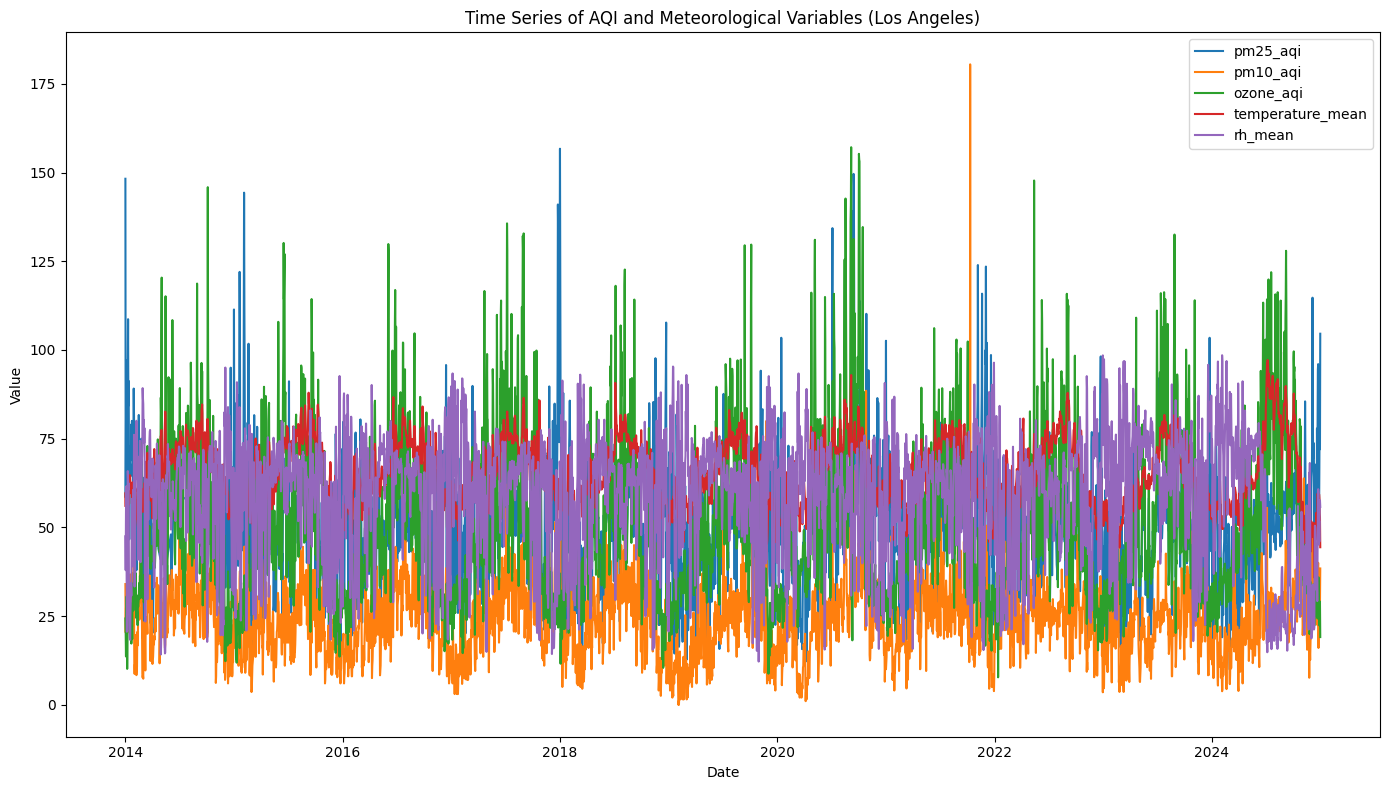

In [8]:
# --- Exploratory Data Analysis (EDA) ---
# 1. Time Series Plot for AQI and Key Variables
plt.figure(figsize=(14, 8))
for col in ['pm25_aqi', 'pm10_aqi', 'ozone_aqi', 'temperature_mean', 'rh_mean']:
    if col in combined_df.columns:
        plt.plot(combined_df.index, combined_df[col], label=col)
plt.title('Time Series of AQI and Meteorological Variables (Los Angeles)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.savefig('/content/eda_time_series.png')
plt.show()

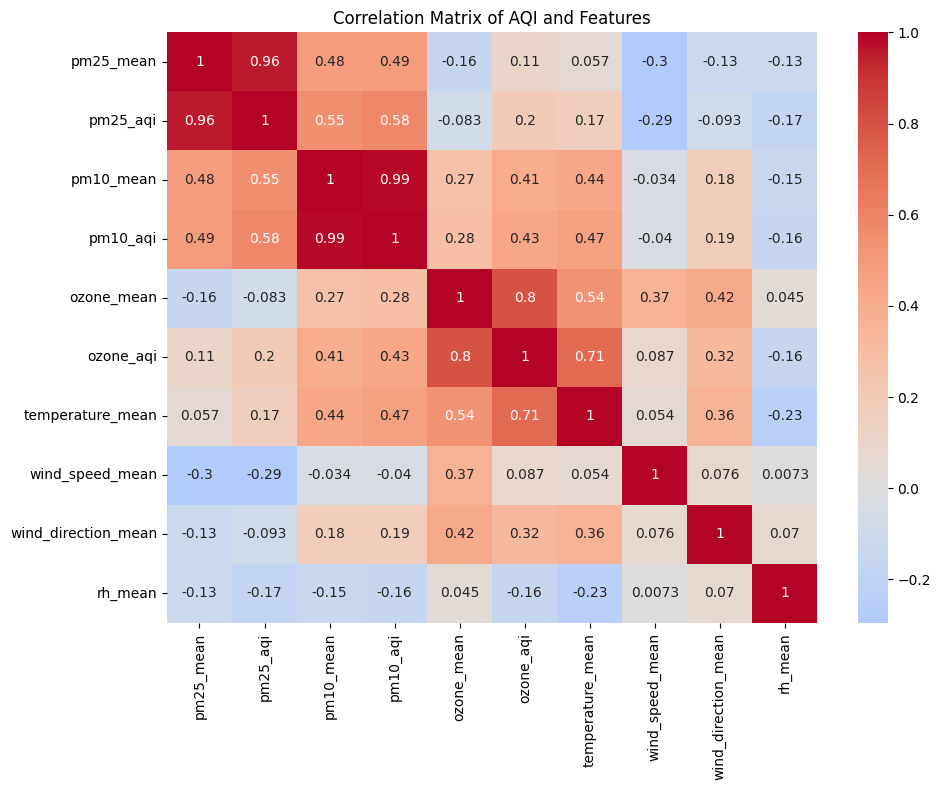

In [9]:
# 2. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(combined_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of AQI and Features')
plt.tight_layout()
plt.savefig('/content/eda_correlation.png')
plt.show()

date_local
2014-01-01    148.250000
2014-01-02     58.375000
2014-01-03     75.666667
2014-01-04     97.000000
2014-01-05     65.222222
Name: pm25_aqi, dtype: float64


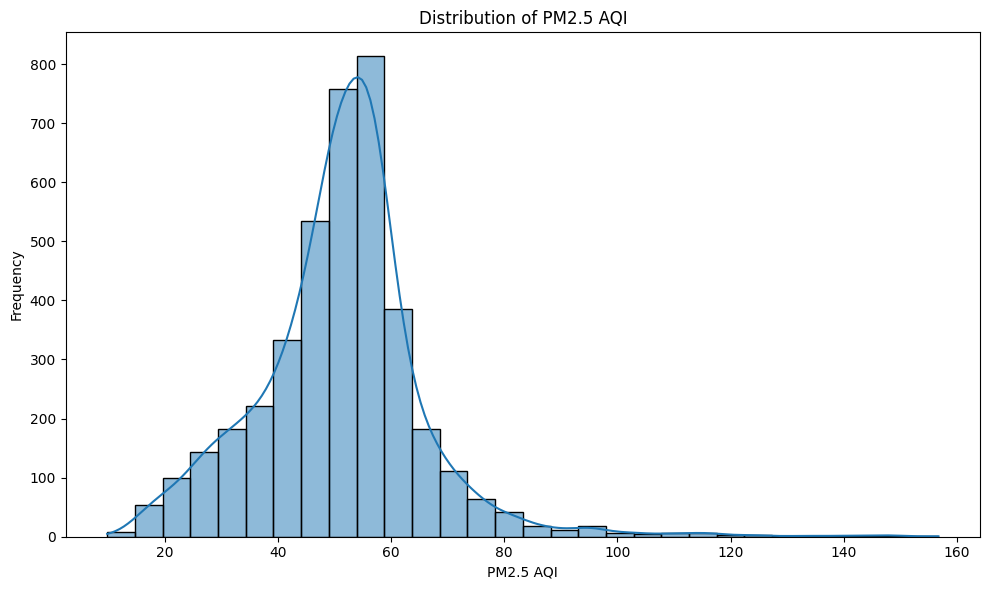

In [10]:
# 3. Distribution of PM2.5 AQI
print(combined_df['pm25_aqi'].head(5))
plt.figure(figsize=(10, 6))
sns.histplot(combined_df['pm25_aqi'].dropna(), bins=30, kde=True)
plt.title('Distribution of PM2.5 AQI')
plt.xlabel('PM2.5 AQI')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('/content/eda_pm25_distribution.png')
plt.show()

In [11]:
# # --- Prepare Data for Modeling ---
# # Focus on PM2.5 AQI for ARIMA
# if 'pm25_aqi' not in combined_df.columns:
#     raise ValueError("'pm25_aqi' column not found in combined_df. Cannot proceed with modeling.")
# aqi_series = combined_df['pm25_aqi'].dropna()

# --- Prepare Data for Modeling ---
# Calculate combined AQI (example weights based on EPA contributions)
combined_df['combined_aqi'] = (0.4 * combined_df['pm25_aqi'].fillna(0) +
                              0.3 * combined_df['pm10_aqi'].fillna(0) +
                              0.3 * combined_df['ozone_aqi'].fillna(0))
target = 'combined_aqi'
print(f"Modeling target: {target}")
series = combined_df[target].dropna()
print(f"Length of series: {len(series)}")
print(f"First few values of series:\n{series.head(5)}")

Modeling target: combined_aqi
Length of series: 4018
First few values of series:
date_local
2014-01-01    76.792308
2014-01-02    35.519231
2014-01-03    42.543590
2014-01-04    54.615385
2014-01-05    44.250427
Name: combined_aqi, dtype: float64


In [12]:
# # Train-test split (80-20)
# train_size = int(len(aqi_series) * 0.8)
# if train_size < 10:
#     raise ValueError(f"Train size ({train_size}) is too small for modeling. Check data availability.")
# train, test = aqi_series[:train_size], aqi_series[train_size:]

# Train-test split (80-20)
train_size = int(len(series) * 0.8)
if train_size < 10:
    raise ValueError(f"Train size ({train_size}) is too small for modeling. Check data availability.")
train, test = series[:train_size], series[train_size:]
print(f"Train size: {len(train)}, Test size: {len(test)}")

Train size: 3214, Test size: 804


In [13]:
# # --- ARIMA Model ---
# # Auto-tune ARIMA parameters
# p = d = q = range(0, 2)
# pdq = list(product(p, d, q))
# seasonal_pdq = [(x[0], x[1], x[2], 12) for x in pdq]
# best_aic = np.inf
# best_params = None

# for param in pdq:
#     for param_seasonal in seasonal_pdq:
#         try:
#             mod = SARIMAX(train, order=param, seasonal_order=param_seasonal, enforce_stationarity=False, enforce_invertibility=False)
#             results = mod.fit(disp=False)
#             if results.aic < best_aic:
#                 best_aic = results.aic
#                 best_params = (param, param_seasonal)
#         except:
#             continue

# print(f"Best ARIMA params: {best_params}")

# --- ARIMA Model ---
from pmdarima import auto_arima
model = auto_arima(train, seasonal=False, trace=True)
arima_results = model.fit(train)
arima_forecast = arima_results.forecast(steps=len(test))
arima_forecast_7day = arima_results.forecast(steps=7)
arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
print(f"ARIMA MAE: {arima_mae:.2f}, RMSE: {arima_rmse:.2f}")

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
# Fit best ARIMA model
# order, seasonal_order = best_params
# arima_model = SARIMAX(train, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
# arima_results = arima_model.fit(disp=False)

In [ ]:
# Forecast
# arima_forecast = arima_results.forecast(steps=len(test))
# arima_forecast_7day = arima_results.forecast(steps=7)

In [ ]:
# Evaluate ARIMA
# arima_mae = mean_absolute_error(test, arima_forecast)
# arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
# print(f"ARIMA MAE: {arima_mae:.2f}, RMSE: {arima_rmse:.2f}")

In [ ]:
# --- Random Forest Model ---
# Prepare data for Random Forest (multivariate)
# features = [col for col in combined_df.columns if '_mean' in col or '_aqi' in col]
# X = combined_df[features].dropna()
# y = combined_df['pm25_aqi'].loc[X.index]

In [ ]:
# Scale features
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

In [ ]:
# Train-test split
# X_train, X_test = X_scaled[:train_size], X_scaled[train_size:]
# y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
# Train Random Forest
# rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
# rf_model.fit(X_train, y_train)

In [ ]:
# Forecast
# rf_forecast = rf_model.predict(X_test)
# # 7-day forecast (use last 7 days of scaled data)
# rf_forecast_7day = rf_model.predict(X_scaled[-7:])

In [ ]:
# Evaluate Random Forest
# rf_mae = mean_absolute_error(y_test, rf_forecast)
# rf_rmse = np.sqrt(mean_squared_error(y_test, rf_forecast))
# print(f"Random Forest MAE: {rf_mae:.2f}, RMSE: {rf_rmse:.2f}")

In [ ]:
# --- Random Forest Model ---
features = [col for col in combined_df.columns if '_mean' in col or '_aqi' in col]
if not features:
    print("Warning: No features available for Random Forest. Skipping RF modeling.")
    rf_mae = rf_rmse = rf_forecast = rf_forecast_7day = None
else:
    X = combined_df[features].dropna()
    y = combined_df[target].loc[X.index]
    print(f"Random Forest features: {features}")
    print(f"Shape of X: {X.shape}, Shape of y: {y.shape}")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test = X_scaled[:train_size], X_scaled[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
    rf_model.fit(X_train, y_train)
    rf_forecast = rf_model.predict(X_test)
    rf_forecast_7day = rf_model.predict(X_scaled[-7:])
    rf_mae = mean_absolute_error(y_test, rf_forecast)
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_forecast))
    print(f"Random Forest MAE: {rf_mae:.2f}, RMSE: {rf_rmse:.2f}")

In [ ]:
# --- Enhanced Visualization with Accuracy Metrics ---
# 1. Forecast Comparison Plot with Metrics
plt.figure(figsize=(14, 8))
plt.plot(test.index, test, label='Actual PM2.5 AQI', color='blue')
plt.plot(test.index, arima_forecast, label=f'ARIMA Forecast (MAE: {arima_mae:.2f}, RMSE: {arima_rmse:.2f})', color='red')
plt.plot(test.index, rf_forecast, label=f'Random Forest Forecast (MAE: {rf_mae:.2f}, RMSE: {rf_rmse:.2f})', color='green')
plt.title('AQI Forecast Comparison (Test Set)')
plt.xlabel('Date')
plt.ylabel('PM2.5 AQI')
plt.legend()
plt.tight_layout()
plt.savefig('/content/forecast_comparison.png')
plt.show()

In [ ]:
# 2. 7-Day Forecast Plot
future_dates = pd.date_range(start=aqi_series.index[-1] + pd.Timedelta(days=1), periods=7)
plt.figure(figsize=(10, 6))
plt.plot(future_dates, arima_forecast_7day, label='ARIMA 7-day Forecast', color='red')
plt.plot(future_dates, rf_forecast_7day, label='Random Forest 7-day Forecast', color='green')
plt.title('7-Day PM2.5 AQI Forecast')
plt.xlabel('Date')
plt.ylabel('PM2.5 AQI')
plt.legend()
plt.tight_layout()
plt.savefig('/content/7day_forecast.png')
plt.show()

In [ ]:
# 3. Accuracy Metrics Bar Plot
metrics = pd.DataFrame({
    'Model': ['ARIMA', 'Random Forest'],
    'MAE': [arima_mae, rf_mae],
    'RMSE': [arima_rmse, rf_rmse]
})
plt.figure(figsize=(8, 6))
metrics.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar')
plt.title('Model Performance Comparison')
plt.ylabel('Error')
plt.tight_layout()
plt.savefig('/content/model_metrics.png')
plt.show()

In [ ]:
# --- Save Results ---
# Save forecasts
results = pd.DataFrame({
    'Date': future_dates,
    'ARIMA_Forecast': arima_forecast_7day,
    'Random_Forest_Forecast': rf_forecast_7day
})
results.to_csv('/content/aqi_forecast_results.csv', index=False)

# Save metrics
metrics.to_csv('/content/model_metrics.csv', index=False)
print("Results saved to 'aqi_forecast_results.csv' and 'bjmodel_metrics.csv'")

In [ ]:
!pip install pmdarima

In [ ]:
!pip uninstall numpy pmdarima -y
!pip install numpy pmdarima